In [83]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

Введение

В данном проекте проводится исследовательский анализ данных (EDA) датасета Superstore. Датасет содержит информацию о заказах, клиентах, товарах, продажах, скидках и прибыли.





Цель анализа — изучить основные характеристики данных, выявить закономерности и потенциальные проблемные зоны, которые могут влиять на прибыльность бизнеса.

В рамках исследования будут рассмотрены:

* структура и качество данных;
* выявленные аномалии;
* распределения основных показателей и потенциальные точки для дальнейшего анализа;
* динамика продаж и прибыли;
* маржинальность категорий и подкатегорий товаров;
* формулировка вывода на основе анализа и рекомендации для дальнейшего исследования и принятия решений.

В результате анализа будут сформулированы основные выводы, гипотезы и возможные бизнес-рекомендации.

I. Октрытие датасета

In [84]:
df = pd.read_csv('superstore.csv')

In [85]:
pd.set_option('display.max_columns', None)

In [86]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2017-152156,11/8/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2.0,0.00,41.9136
1,2,CA-2017-152156,11/8/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3.0,0.00,219.5820
2,3,CA-2017-138688,6/12/2017,6/16/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2.0,0.00,6.8714
3,4,US-2016-108966,10/11/2016,10/18/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5.0,0.45,-383.0310
4,5,US-2016-108966,10/11/2016,10/18/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2.0,0.20,2.5164


In [87]:
df.shape #размер датафрейма

(10800, 21)

II. Очистка данных от Nan и работа с дубликатами

In [88]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10800 entries, 0 to 10799
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         10800 non-null  object 
 1   Order ID       10800 non-null  object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9983 non-null   float64
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quanti

In [89]:
df.isna().sum().sort_values(ascending=False) # кол-во Nan в датафрейме

,0
Postal Code,817
Ship Mode,806
Ship Date,806
Customer ID,806
Order Date,806
Product ID,806
Category,806
Segment,806
Customer Name,806
Country,806


Во многих столбцах наблюдается одинаковое количество Nan. Возможно имеются строки, в котором во всех столбцах, за исключением первых двух, стоят Nan.

In [90]:
df.duplicated().sum() # кол-во дубликатов

np.int64(504)

In [91]:
empty_rows = df[df.iloc[:, 2:].isna().all(axis=1)] # датафрейм из пустых строк (кроме первых двух столбцов)
# начального датафрейма

In [92]:
empty_rows.shape

(806, 21)

In [93]:
empty_rows.duplicated().sum()

np.int64(504)

В полученном датафрейме всего 806 строк (за исключением данных в первых двух столбцах) из которых все 806 строк - пустые, а 504 строк - дубликаты, что совпадает с теми же показателями об исходном датафрейме. Выходит, что все 806 Nan в столбцах расположены в пустых строках, а за счет повторяющихся значений в первых двух столбцах, имеются дубликаты пустых строк в датафрейме.

Так как таких строк 806, а всего данных 10800, то можно удалить пустые строки без потери информации.

In [94]:
df = df[~df.iloc[:, 2:].isna().all(axis=1)]

In [95]:
df.shape

(9994, 21)

In [96]:
df.duplicated().sum()

np.int64(0)

In [97]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   object 
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9983 non-null   float64
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity     

Теперь в датафрейме отсутствуют дубликаты. Nan остались в 11 строках в колонке с почтовым индексом. С учетом того, что в данных есть описание региона, штата и города заказчика, то данный признак не является критическим.

In [98]:
df[df['Postal Code'].isna()] # оставшиеся Nan в столбце почтового индекса

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
2234,2235,CA-2018-104066,12/5/2018,12/10/2018,Standard Class,QJ-19255,Quincy Jones,Corporate,United States,Burlington,Vermont,NaN,East,TEC-AC-10001013,Technology,Accessories,Logitech ClearChat Comfort/USB Headset H390,205.03,7.0,0.0,67.6599
5274,5275,CA-2016-162887,11/7/2016,11/9/2016,Second Class,SV-20785,Stewart Visinsky,Consumer,United States,Burlington,Vermont,NaN,East,FUR-CH-10000595,Furniture,Chairs,Safco Contoured Stacking Chairs,715.20,3.0,0.0,178.8000
8798,8799,US-2017-150140,4/6/2017,4/10/2017,Standard Class,VM-21685,Valerie Mitchum,Home Office,United States,Burlington,Vermont,NaN,East,TEC-PH-10002555,Technology,Phones,Nortel Meridian M5316 Digital phone,1294.75,5.0,0.0,336.6350
9146,9147,US-2017-165505,1/23/2017,1/27/2017,Standard Class,CB-12535,Claudia Bergmann,Corporate,United States,Burlington,Vermont,NaN,East,TEC-AC-10002926,Technology,Accessories,Logitech Wireless Marathon Mouse M705,99.98,2.0,0.0,42.9914
9147,9148,US-2017-165505,1/23/2017,1/27/2017,Standard Class,CB-12535,Claudia Bergmann,Corporate,United States,Burlington,Vermont,NaN,East,OFF-AR-10003477,Office Supplies,Art,4009 Highlighters,8.04,6.0,0.0,2.7336
9148,9149,US-2017-165505,1/23/2017,1/27/2017,Standard Class,CB-12535,Claudia Bergmann,Corporate,United States,Burlington,Vermont,NaN,East,OFF-ST-10001526,Office Supplies,Storage,Iceberg Mobile Mega Data/Printer Cart,1564.29,13.0,0.0,406.7154
9386,9387,US-2018-127292,1/19/2018,1/23/2018,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,Vermont,NaN,East,OFF-PA-10000157,Office Supplies,Paper,Xerox 191,79.92,4.0,0.0,37.5624
9387,9388,US-2018-127292,1/19/2018,1/23/2018,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,Vermont,NaN,East,OFF-PA-10001970,Office Supplies,Paper,Xerox 1881,12.28,1.0,0.0,5.7716
9388,9389,US-2018-127292,1/19/2018,1/23/2018,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,Vermont,NaN,East,OFF-AP-10000828,Office Supplies,Appliances,Avanti 4.4 Cu. Ft. Refrigerator,542.94,3.0,0.0,152.0232
9389,9390,US-2018-127292,1/19/2018,1/23/2018,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,Vermont,NaN,East,OFF-EN-10001509,Office Supplies,Envelopes,Poly String Tie Envelopes,2.04,1.0,0.0,0.9588


Интересно отметить, что все 11 Nan в столбце почтового индекса связаны с городом Burlington, штат Vermont.

III. Распределение данных

In [99]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Postal Code,9983.0,55245.233297,32038.715955,1040.000,23223.00000,57103.0000,90008.000,99301.000
Sales,9994.0,229.858001,623.245101,0.444,17.28000,54.4900,209.940,22638.480
Quantity,9994.0,3.789574,2.225110,1.000,2.00000,3.0000,5.000,14.000
Discount,9994.0,0.156203,0.206452,0.000,0.00000,0.2000,0.200,0.800
Profit,9994.0,28.656896,234.260108,-6599.978,1.72875,8.6665,29.364,8399.976


In [100]:
(df['Discount'] > 0.2).mean() * 100 # процент заказов со скидкой больше, чем 20%

np.float64(13.938363017810687)

In [101]:
(df['Profit'] < 0).mean() * 100 # процент убыточных закаов

np.float64(18.721232739643785)

1) Признак "Sales" смещен вправо, так как среднее значении больше значения медианы, что говорит о влиянии выбросов (дорогих заказов).
2) Признак "Quantity" выглядит стабильным.
3) Признак "Discount" сильно ограничен, так как значение медианы и 75%-квантиля равны 20%, при этом количество заказов со скидкой более 20% составляет 14%.
4) Признак "Profit" имеет высокую вариативность данных. Имеються выбросы среди как убыточных заказов, так и прибыльных. Однако не смотря на то, что средние и медианные значения больше нуля, 19% заказов при этом убыточны.

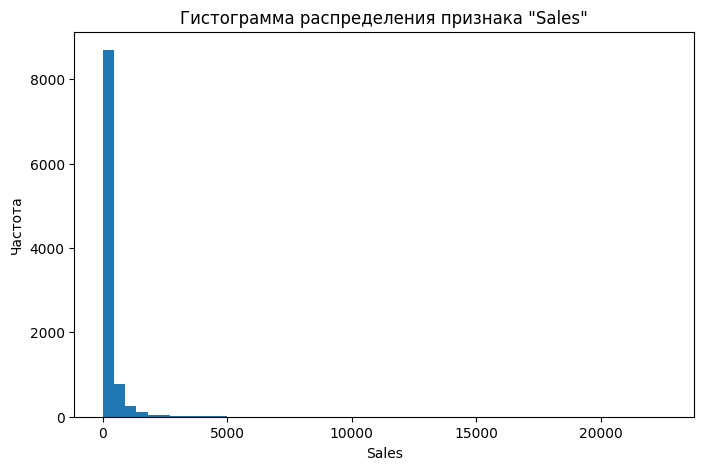

In [102]:
plt.figure(figsize=(8, 5))
plt.hist(df['Sales'], bins=50)
plt.title('Гистограмма распределения признака "Sales"')
plt.xlabel('Sales')
plt.ylabel('Частота')
plt.show()

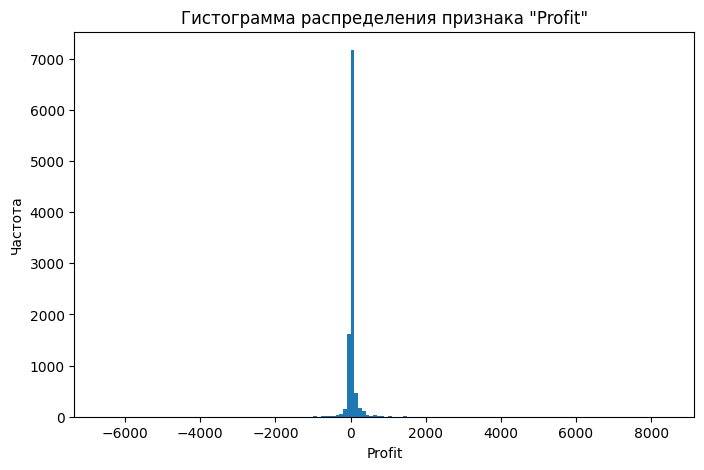

In [103]:
plt.figure(figsize=(8, 5))
plt.hist(df['Profit'], bins=150)
plt.title('Гистограмма распределения признака "Profit"')
plt.xlabel('Profit')
plt.ylabel('Частота')
plt.show()

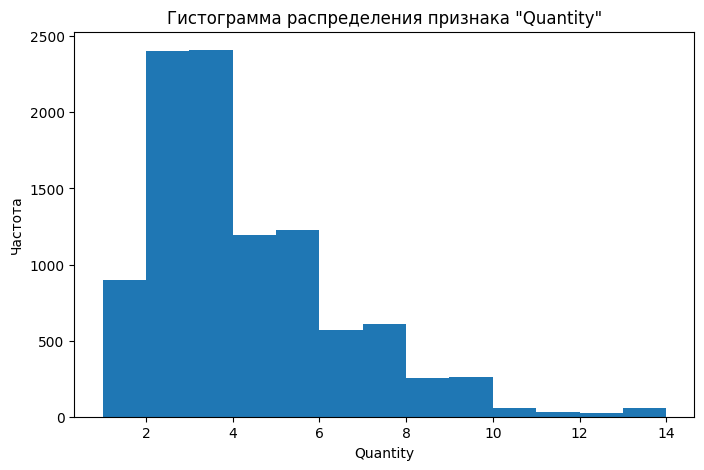

In [104]:
plt.figure(figsize=(8, 5))
plt.hist(df['Quantity'], bins=13)
plt.title('Гистограмма распределения признака "Quantity"')
plt.xlabel('Quantity')
plt.ylabel('Частота')
plt.show()

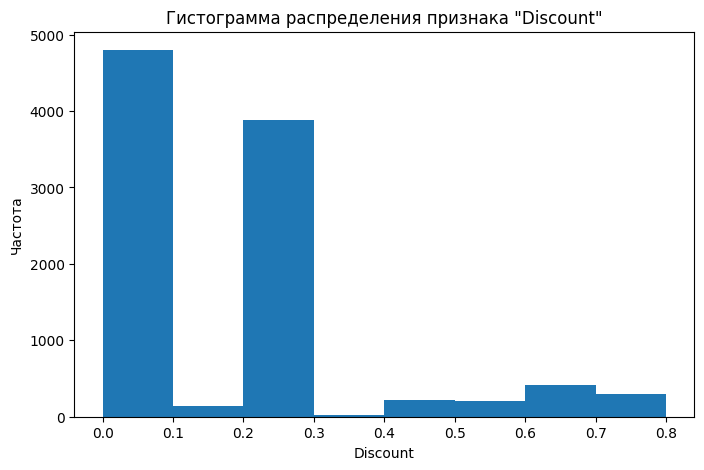

In [105]:
plt.figure(figsize=(8, 5))
plt.hist(df['Discount'], bins=8)
plt.title('Гистограмма распределения признака "Discount"')
plt.xlabel('Discount')
plt.ylabel('Частота')
plt.show()

In [106]:
"""
Функция построения круговых диаграм для категориальных данных. Входные параметры:
column - признак, по которому строиться распределение
breakpoint - пороговый процент. Все категории, которые имеют меньшую долю в распределении,
чем значение breakpoint, учитываются в категории "Other".
"""
def pie_chart(column, breakpoint = 10):
  df_value = df[column].value_counts(normalize = True)
  main_value = df_value[df_value >= (breakpoint / 100)] # основные категории
  other_value = df_value[df_value < (breakpoint / 100)].sum() # категория "Other"
  if other_value:
    result_value = pd.concat([
      main_value,
      pd.Series({'Other': other_value})
    ])
  else:
    result_value = df_value.copy()
  result_value.plot(
      kind='pie',
      autopct='%1.1f%%',
      figsize=(6, 6)
  )
  plt.title(f'Распределение по {column}')
  plt.ylabel('')
  plt.show()

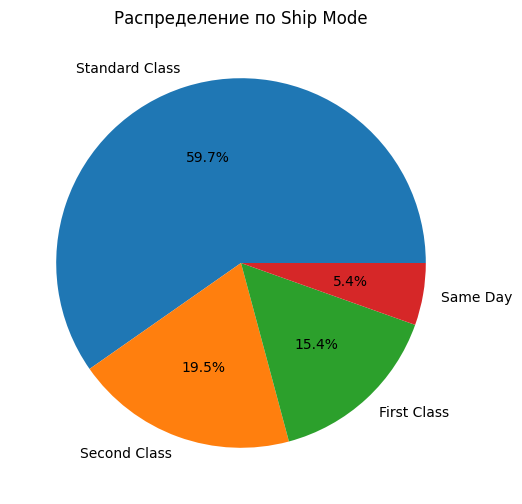

In [107]:
pie_chart('Ship Mode', 1)

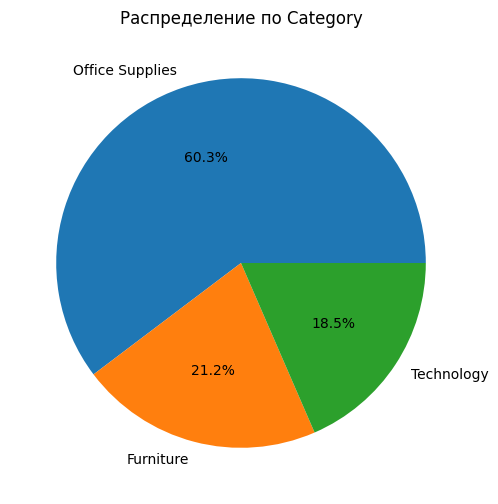

In [108]:
pie_chart('Category')

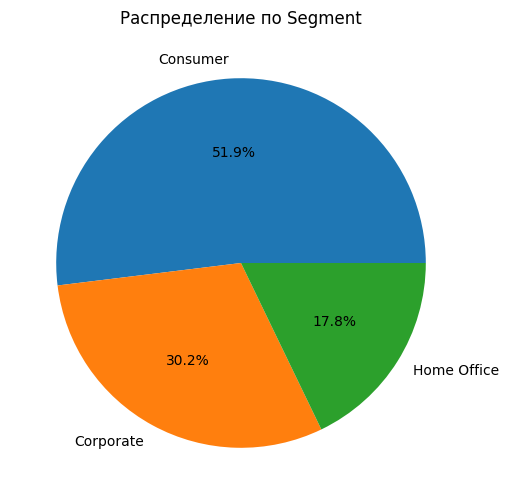

In [109]:
pie_chart('Segment')

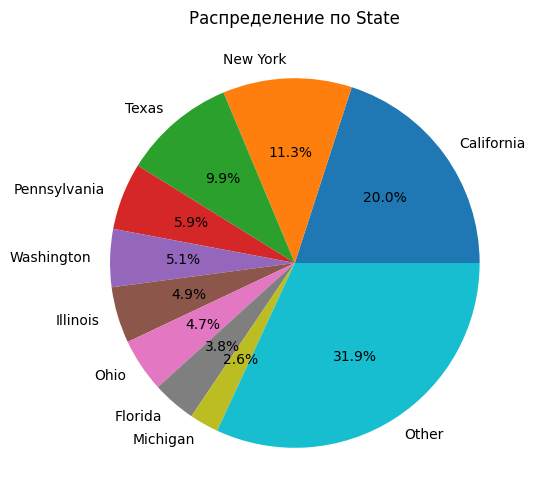

In [110]:
pie_chart('State', 2.5)

В штате Калифорния больше всех совершают покупок, каждый 5 заказ приходится на этот штат. Следующие за ней Техас и Нью Йорк имеют примерно равыне доли.

Условно распределение можно разделить на 3 группы:
1) Штаты Калифорния и Нью Йорк. Калифорния, как первый штат по размеру ВВП в США и Нью Йорк, как экономический и финансовый центр страны.
2) Штаты, на которые приходяться не более 2.5% заказов. В основном это менее развитые штаты или штаты с меньшим количеством населения.
3) Штаты, на которые приходяться от 10% до 2.5%. В основном это развитые штаты: второй по величине ВВП Техас, штат Вашингтон, где расположены офисы и производства крупных компаний (Боинг, Майкрософт), конкурирующая с Нью Йорком на восточном побережье Флорида и штаты ржавого пояса.


Стоит отметить, что на каждую группу приходиться примерно 1/3 распределения.

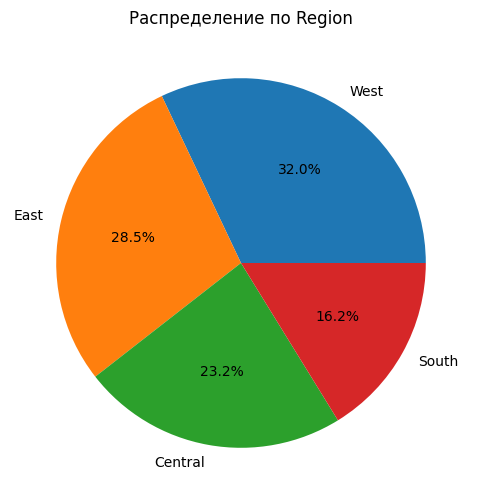

In [111]:
pie_chart('Region')

In [112]:
(df['City'].value_counts(normalize=True) * 100).round(2).head(20) # топ-20 городов по заказам

,proportion
City,
New York City,9.16
Los Angeles,7.47
Philadelphia,5.37
San Francisco,5.10
Seattle,4.28
Houston,3.77
Chicago,3.14
Columbus,2.22
San Diego,1.70


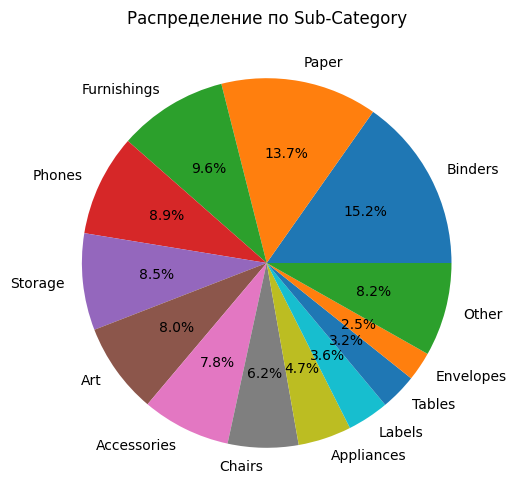

In [113]:
pie_chart('Sub-Category', 2.5)

IV. Анализ маржинальности товаров

In [114]:
category_stats = (
    df.groupby('Category')
      .agg(
          Sales=('Sales', 'sum'),
          Profit=('Profit', 'sum'),
          Orders=('Order ID', 'nunique')
      )
)

category_stats['Margin'] = (
    category_stats['Profit'] /
    category_stats['Sales'] * 100
)

category_stats.sort_values('Margin', ascending=False)

,Sales,Profit,Orders,Margin
Category,,,,
Technology,836154.0330,145454.9481,1544,17.395712
Office Supplies,719047.0320,122490.8008,3742,17.035158
Furniture,741999.7953,18451.2728,1764,2.486695


Маржинальность по категории "Мебель" значительно меньше, чем по остальным. Можно предположить, что основная доля убыточных заказов приходиться на эту категорию.

In [115]:
subcategory_stats = (
    df.groupby('Sub-Category')
      .agg(
          Sales=('Sales', 'sum'),
          Profit=('Profit', 'sum'),
          Orders=('Order ID', 'nunique')
      )
)

subcategory_stats['Margin'] = (
    subcategory_stats['Profit'] /
    subcategory_stats['Sales'] * 100
)

subcategory_stats.sort_values('Margin')

,Sales,Profit,Orders,Margin
Sub-Category,,,,
Tables,206965.5320,-17725.4811,307,-8.564460
Bookcases,114879.9963,-3472.5560,224,-3.022768
Supplies,46673.5380,-1189.0995,187,-2.547695
Machines,189238.6310,3384.7569,112,1.788618
Chairs,328449.1030,26590.1663,576,8.095673
Storage,223843.6080,21278.8264,777,9.506113
Phones,330007.0540,44515.7306,814,13.489327
Furnishings,91705.1640,13059.1436,877,14.240358
Binders,203412.7330,30221.7633,1316,14.857361


In [116]:
shipmode_stats = (
    df.groupby('Ship Mode')
      .agg(
          Sales=('Sales', 'sum'),
          Profit=('Profit', 'sum'),
          Orders=('Order ID', 'nunique')
      )
)

shipmode_stats['Margin'] = (
    shipmode_stats['Profit'] /
    shipmode_stats['Sales'] * 100
)

shipmode_stats.sort_values('Margin')

,Sales,Profit,Orders,Margin
Ship Mode,,,,
Standard Class,1.358216e+06,164088.7875,2994,12.081202
Same Day,1.283631e+05,15891.7589,264,12.380315
Second Class,4.591936e+05,57446.6354,964,12.510331
First Class,3.514284e+05,48969.8399,787,13.934513


Сильных различий в типах доставок нет. Более премиальные доставки имеют чуть большую маржинальность, что закономерно.

In [117]:
segment_stats = (
    df.groupby('Segment')
      .agg(
          Sales=('Sales', 'sum'),
          Profit=('Profit', 'sum'),
          Orders=('Order ID', 'nunique')
      )
)

segment_stats['Margin'] = (
    segment_stats['Profit'] /
    segment_stats['Sales'] * 100
)

segment_stats.sort_values('Margin')

,Sales,Profit,Orders,Margin
Segment,,,,
Consumer,1.161401e+06,134119.2092,2586,11.548050
Corporate,7.061464e+05,91979.1340,1514,13.025506
Home Office,4.296531e+05,60298.6785,909,14.034269


In [118]:
region_stats = (
    df.groupby('Region')
      .agg(
          Sales=('Sales', 'sum'),
          Profit=('Profit', 'sum'),
          Orders=('Order ID', 'nunique')
      )
)

region_stats['Margin'] = (
    region_stats['Profit'] /
    region_stats['Sales'] * 100
)

region_stats.sort_values('Margin')

,Sales,Profit,Orders,Margin
Region,,,,
Central,501239.8908,39706.3625,1175,7.921629
South,391721.9050,46749.4303,822,11.934342
East,678781.2400,91522.7800,1401,13.483399
West,725457.8245,108418.4489,1611,14.944831


Центральный регион имеют меньшую маржинальность. Возможно в данном регионе больше доля убыточных заказов или корзина товаров содержит менее маржинальные категории.

In [119]:
discount_stats = (
    df.groupby('Discount')
      .agg(
          Sales=('Sales', 'sum'),
          Profit=('Profit', 'sum'),
          Orders=('Order ID', 'nunique')
      )
)

discount_stats['Margin'] = (
    discount_stats['Profit'] /
    discount_stats['Sales'] * 100
)

discount_stats.sort_values('Margin')

,Sales,Profit,Orders,Margin
Discount,,,,
0.80,1.696376e+04,-30539.0392,250,-180.025221
0.70,4.062028e+04,-40075.3569,344,-98.658490
0.60,6.644700e+03,-5944.6552,127,-89.464614
0.45,5.484974e+03,-2493.1111,10,-45.453472
0.50,5.891854e+04,-20506.4281,64,-34.804712
0.40,1.164178e+05,-23057.0504,185,-19.805437
0.32,1.449346e+04,-2391.1377,27,-16.498047
0.30,1.032267e+05,-10369.2774,211,-10.045155
0.15,2.755852e+04,1418.9915,51,5.149012


По мере увеличения размера скидки маржинальность уменьшается, а после 20% становиться убыточной.

In [120]:
margin = df['Profit'].sum() / df['Sales'].sum() * 100
margin

np.float64(12.467217240315604)

In [121]:
profit_margin = df[df['Profit'] > 0]['Profit'].sum() / df[df['Profit'] > 0]['Sales'].sum() * 100
profit_margin

np.float64(24.573890604159978)

In [122]:
del_margin = profit_margin - margin
del_margin

np.float64(12.106673363844374)

Общая маржинальность составила 12%, тогда как маржинальность по прибыльным заказам составила 25%, что более чем в 2 раза больше. Это может говорить о существенном влиянии убыточных товаров на прибыль. Поэтому важно разобраться в причинах убыточности заказов.

IV. Анализ убыточных заказов

In [123]:
loss_by_category = (
    df.assign(Is_Loss=df['Profit'] < 0)
      .groupby('Category')
      .agg(
          Loss_Lines=('Is_Loss', 'sum'),
          Total_Lines=('Is_Loss', 'count'),
          Loss_Rate=('Is_Loss', 'mean'),
          Total_Loss=('Profit', lambda x: x[x < 0].sum())
      )
)

loss_by_category['Loss_Rate'] *= 100 # перевод в проценты

loss_by_category.sort_values('Loss_Rate', ascending=False)

,Loss_Lines,Total_Lines,Loss_Rate,Total_Loss
Category,,,,
Furniture,714,2121,33.663366,-60936.1090
Office Supplies,886,6026,14.702954,-56615.2585
Technology,271,1847,14.672442,-38579.9182


In [124]:
loss_distribution = (
    df[df['Profit'] < 0]['Category']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

loss_distribution

,proportion
Category,
Office Supplies,47.35
Furniture,38.16
Technology,14.48


Каждый третий заказ мебели убыточен, что сильно выделяет данную категорию среди других, у которых данный показатель менее 15%. Это подтвержает ранее выдвинутую гипотезу о доли убыточных заказов мебели.

In [125]:
loss_by_subcategory = (
    df.assign(Is_Loss=df['Profit'] < 0)
      .groupby('Sub-Category')
      .agg(
          Loss_Lines=('Is_Loss', 'sum'),
          Total_Lines=('Is_Loss', 'count'),
          Loss_Rate=('Is_Loss', 'mean'),
          Total_Loss=('Profit', lambda x: x[x < 0].sum())
    )
)

loss_by_subcategory['Loss_Rate'] *= 100

loss_by_subcategory.sort_values('Loss_Rate', ascending = False)

,Loss_Lines,Total_Lines,Loss_Rate,Total_Loss
Sub-Category,,,,
Tables,203,319,63.636364,-32412.1483
Bookcases,109,228,47.807018,-12152.2060
Binders,613,1523,40.249508,-38510.4964
Machines,44,115,38.260870,-30118.6682
Chairs,235,617,38.087520,-9880.8413
Storage,161,846,19.030733,-6426.3038
Furnishings,167,957,17.450366,-6490.9134
Supplies,33,190,17.368421,-3015.6219
Phones,136,889,15.298088,-7530.6235


В топ-5 самых убыточных подкатегорий (по процентному соотношению) входят: Tabels, Bookcases, Binders, Machines, Chairs. 3 подкатегории из категории мебели, одна из техники и одна - офисные принадлежности.

In [126]:
loss_by_discount = (
    df.assign(Is_Loss=df['Profit'] < 0)
      .groupby('Discount')
      .agg(
          Loss_Rate=('Is_Loss', 'mean'),
          Avg_Profit=('Profit', 'mean'),
          Sales=('Sales', 'sum'),
          Profit=('Profit', 'sum')
      )
)

loss_by_discount['Loss_Rate'] *= 100

loss_by_discount

,Loss_Rate,Avg_Profit,Sales,Profit
Discount,,,,
0.00,0.000000,66.900292,1.087908e+06,320987.6032
0.10,4.255319,96.055074,5.436935e+04,9029.1770
0.15,32.692308,27.288298,2.755852e+04,1418.9915
0.20,13.727099,24.702572,7.645944e+05,90337.3060
0.30,91.629956,-45.679636,1.032267e+05,-10369.2774
0.32,100.000000,-88.560656,1.449346e+04,-2391.1377
0.40,87.378641,-111.927429,1.164178e+05,-23057.0504
0.45,100.000000,-226.646464,5.484974e+03,-2493.1111
0.50,100.000000,-310.703456,5.891854e+04,-20506.4281


Заказы, со скидкой более чем 20%, убыточны по общей прибыли. Более того только для 30% и 40% имеются прибыльные заказы, однако подавляющее большинство заказов - убыточные (91% и 87%, соответственно). Для других размеров скидок все заказы убыточные.

In [127]:
orders_by_discount = (
    df.groupby(['Category', 'Discount'])['Order ID']
      .nunique()
      .unstack(fill_value=0)
)

orders_by_discount

Discount,0.00,0.10,0.15,0.20,0.30,0.32,0.40,0.45,0.50,0.60,0.70,0.80
Category,,,,,,,,,,,,
Furniture,739,71,51,539,207,27,72,10,53,127,15,0
Office Supplies,2020,16,0,1661,0,0,0,0,0,0,323,250
Technology,718,2,0,744,5,0,118,0,11,0,22,0


In [128]:
discount_over_20 = (
    df.assign(High_Discount=df['Discount'] > 0.2)
      .groupby('Category')['High_Discount']
      .mean()
      .mul(100)
      .round(2)
)

discount_over_20

,High_Discount
Category,
Furniture,25.55
Office Supplies,11.28
Technology,9.26


Четверть заказов мебели идут со скидкой большей, чем 20%, при том, что такие заказы имеют отрицательую маржинальность и высокую долю убыточных заказов. Это может является причиной низкой маржинальности товаров по данной категории. Возможно, маркетплейс использует такой размер скидок в качестве стратегии входа на рынок и удержания аудитории.

Для проверки данной гипотезы подробнее рассмотрим категорию "мебель" по подкатегориям.

V. Анализ категории "Furniture"

In [129]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

In [130]:
df['Year'] = df['Order Date'].dt.year

In [131]:
furniture_subcategory = (
    df[df['Category'] == 'Furniture']
    .groupby(['Year', 'Sub-Category'])
    .agg(
        Sales=('Sales', 'sum'),
        Profit=('Profit', 'sum')
    )
)

furniture_subcategory['Margin'] = (
    furniture_subcategory['Profit'] /
    furniture_subcategory['Sales'] * 100
)

furniture_subcategory.round(2)

Sales   Profit  Margin
Year Sub-Category                           
2015 Bookcases     20036.68  -346.17   -1.73
     Chairs        77241.58  6955.05    9.00
     Furnishings   13826.23  1972.89   14.27
     Tables        46088.37 -3124.04   -6.78
2016 Bookcases     38543.57 -2755.23   -7.15
     Chairs        71734.53  6228.42    8.68
     Furnishings   21089.71  3051.82   14.47
     Tables        39150.42 -3509.80   -8.96
2017 Bookcases     26275.47   212.47    0.81
     Chairs        83918.64  5763.15    6.87
     Furnishings   27874.12  3935.27   14.12
     Tables        60833.20 -2950.94   -4.85
2018 Bookcases     30024.28  -583.63   -1.94
     Chairs        95554.35  7643.55    8.00
     Furnishings   28915.09  4099.16   14.18
     Tables        60893.54 -8140.69  -13.37

Видно, что две подкатегориии, а именно столы и книжные полки, показывают отрицательную маржинальность. Стулья также имеют низкую маржинальность (менее 10%).

In [132]:
furniture_discount = (
    df[df['Category'] == 'Furniture']
    .assign(High_Discount=lambda x: x['Discount'] > 0.2)
    .groupby('Sub-Category')['High_Discount']
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

furniture_discount

,High_Discount
Sub-Category,
Tables,55.17
Bookcases,30.70
Chairs,25.61
Furnishings,14.42


В тоже время у этих подкатегорий самые выскоие доли заказов со скидкой более 20%. В случае подкатегории "Tables" таких заказов больше половины.

In [133]:
furniture_yearly = (
    df[df['Category'] == 'Furniture']
    .assign(High_Discount=lambda x: x['Discount'] > 0.2)
    .groupby(['Year', 'Sub-Category'])
    .agg(
        Sales=('Sales', 'sum'),
        Orders=('Order ID', 'count'),
        High_Discount_Orders=('High_Discount', 'sum')
    )
)

furniture_yearly['High_Discount_Rate'] = (
    furniture_yearly['High_Discount_Orders'] /
    furniture_yearly['Orders'] * 100
)

furniture_yearly.round(2)

Sales  Orders  High_Discount_Orders  High_Discount_Rate
Year Sub-Category                                                            
2015 Bookcases     20036.68      37                    10               27.03
     Chairs        77241.58     129                    35               27.13
     Furnishings   13826.23     184                    30               16.30
     Tables        46088.37      71                    40               56.34
2016 Bookcases     38543.57      61                    22               36.07
     Chairs        71734.53     133                    30               22.56
     Furnishings   21089.71     200                    26               13.00
     Tables        39150.42      58                    31               53.45
2017 Bookcases     26275.47      54                    15               27.78
     Chairs        83918.64     165                    46               27.88
     Furnishings   27874.12     257                    43               16.73
     Tables        60833.20      86                    47               54.65
2018 Bookcases     30024.28      76                    23               30.26
     Chairs        95554.35     190                    47               24.74
     Furnishings   28915.09     316                    39               12.34
     Tables        60893.54     104                    58               55.77

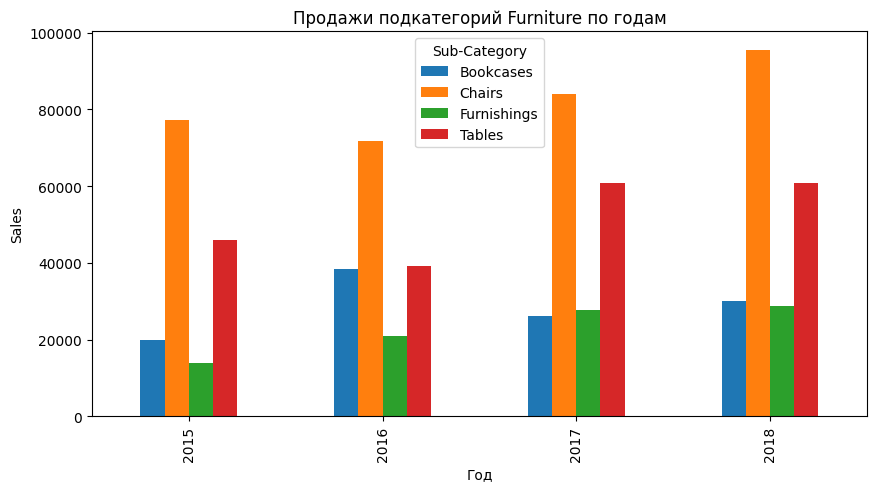

In [134]:
furniture_yearly['Sales'].unstack('Sub-Category').plot(
    kind='bar',
    figsize=(10, 5)
)

plt.title('Продажи подкатегорий Furniture по годам')
plt.xlabel('Год')
plt.ylabel('Sales')
plt.show()

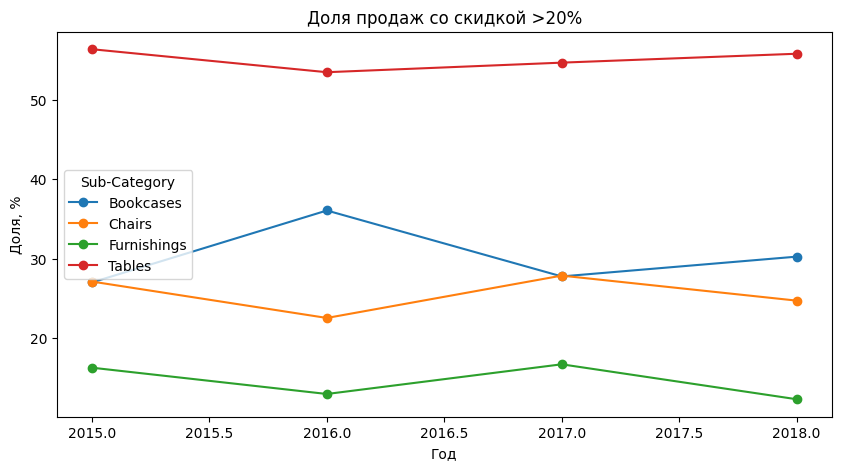

In [135]:
furniture_yearly['High_Discount_Rate'].unstack('Sub-Category').plot(
    kind='line',
    marker='o',
    figsize=(10, 5)
)

plt.title('Доля продаж со скидкой >20%')
plt.xlabel('Год')
plt.ylabel('Доля, %')
plt.show()

Из графиков видно, что большая доля заказов с высокой скидкой не сопровождается ростом продаж. Таким образом, имеющиеся данные не подтверждают гипотезу о том, что высокие скидки способствуют увеличению спроса на данные товары.

Помимо всей категории "Furniture" также стоит рассмотреть подкатегории "Supplies" и "Machines", так как их маржинальность тоже низкая (<5%).

VI. Анализ подкатегории "Supplies".

In [136]:
supplies_discount = (
    df[df['Sub-Category'] == 'Supplies']
    .groupby('Discount')
    .agg(
        Sales=('Sales', 'sum'),
        Profit=('Profit', 'sum'),
        Orders=('Order ID', 'count')
    )
)

supplies_discount['Margin'] = (
    supplies_discount['Profit'] /
    supplies_discount['Sales'] * 100
)

supplies_discount.round(2)


,Sales,Profit,Orders,Margin
Discount,,,,
0.0,31559.21,1718.39,117,5.44
0.2,15114.33,-2907.49,73,-19.24


In [137]:
supplies_loss = (
    df[df['Sub-Category'] == 'Supplies']
    .assign(Is_Loss=lambda x: x['Profit'] < 0)
    .groupby('Discount')
    .agg(
        Loss_Rate=('Is_Loss', 'mean'),
        Sales=('Sales', 'sum'),
        Profit=('Profit', 'sum')
    )
)

supplies_loss['Loss_Rate'] *= 100

supplies_loss.round(2)

,Loss_Rate,Sales,Profit
Discount,,,
0.0,0.00,31559.21,1718.39
0.2,45.21,15114.33,-2907.49


Подкатегория Supplies имеет низкую общую маржинальность −2.55%. Анализ по размеру скидки показывает, что без скидки продажи имеют положительную маржинальность 5.44%, тогда как при скидке 20% маржинальность снижается до −19.24%, а доля убыточных заказов составляет 45.21%.



Таким образом, высокая скидка является потенциальным фактором низкой прибыльности Supplies. Целесообразно дополнительно пересмотреть эффективность предоставления скидки 20% для данной подкатегории.

VII. Анализ подкатегории "Machines"

In [138]:
machines_discount = (
    df[df['Sub-Category'] == 'Machines']
    .groupby('Discount')
    .agg(
        Sales=('Sales', 'sum'),
        Profit=('Profit', 'sum'),
        Orders=('Order ID', 'count')
    )
)

machines_discount['Margin'] = (
    machines_discount['Profit'] /
    machines_discount['Sales'] * 100
)

machines_discount.round(2)

,Sales,Profit,Orders,Margin
Discount,,,,
0.0,71034.00,27137.82,29,38.20
0.1,3410.96,832.08,2,24.39
0.2,37954.57,4970.20,31,13.10
0.3,3756.30,326.04,5,8.68
0.4,19546.22,-2666.84,13,-13.64
0.5,37935.07,-7635.23,12,-20.13
0.7,15601.51,-19579.32,23,-125.50


In [139]:
machines_loss = (
    df[df['Sub-Category'] == 'Machines']
    .assign(Is_Loss=lambda x: x['Profit'] < 0)
    .groupby('Discount')
    .agg(
        Orders=('Order ID', 'count'),
        Loss_Orders=('Is_Loss', 'sum'),
        Sales=('Sales', 'sum'),
        Profit=('Profit', 'sum')
    )
)

machines_loss['Loss_Rate'] = (
    machines_loss['Loss_Orders'] /
    machines_loss['Orders'] * 100
)

machines_loss.round(2)

,Orders,Loss_Orders,Sales,Profit,Loss_Rate
Discount,,,,,
0.0,29,0,71034.00,27137.82,0.00
0.1,2,0,3410.96,832.08,0.00
0.2,31,0,37954.57,4970.20,0.00
0.3,5,1,3756.30,326.04,20.00
0.4,13,8,19546.22,-2666.84,61.54
0.5,12,12,37935.07,-7635.23,100.00
0.7,23,23,15601.51,-19579.32,100.00


Подкатегория Machines имеет низкую общую маржинальность 1.79%, несмотря на значительный объём продаж. Анализ по размеру скидки показывает выраженное снижение прибыльности при увеличении скидки.



При скидках до 20% все заказы в выборке оставались прибыльными, а маржинальность составляла от 13.10% до 38.20%. При скидке 30% доля убыточных заказов составила 20%. Начиная со скидки 40%, более половины заказов становятся убыточными, а при скидках 50% и 70% убыточными являются все заказы.

Таким образом, высокие скидки для Machines связаны с существенным снижением маржинальности. Особенно проблемными выглядят скидки от 40%, которые целесообразно дополнительно пересмотреть.

Также отдельно стоит рассмотреть регион "Central", маржинальность которого была меньше, чем у других регионов.

VIII. Анализ заказов в регионе "Central"

In [140]:
high_discount_region = (
    df
    .groupby(['Region'])
    .agg(
        Orders=('Order ID', 'count'),
        High_Discount_Orders=('Discount', lambda x: (x > 0.2).sum())
    )
)

high_discount_region['High_Discount_Rate'] = (
    high_discount_region['High_Discount_Orders'] /
    high_discount_region['Orders'] * 100
)

high_discount_region.round(2)

,Orders,High_Discount_Orders,High_Discount_Rate
Region,,,
Central,2323,643,27.68
East,2848,461,16.19
South,1620,171,10.56
West,3203,118,3.68


27.68% заказов в Central имеют скидку более 20%. Поскольку ранее было установлено, что заказы с такой скидкой в среднем имеют отрицательную маржинальность, высокая доля таких заказов может быть одним из факторов низкой прибыльности региона. Однако для подтверждения данной гипотезы необходимо дополнительно учитывать структуру продаж региона и вклад отдельных подкатегорий в итоговую прибыль.

In [141]:
central_subcategory = (
    df[df['Region'] == 'Central']
    .groupby('Sub-Category')
    .agg(
        Sales=('Sales', 'sum'),
        Profit=('Profit', 'sum')
    )
)

central_subcategory['Sales_Share'] = (
    central_subcategory['Sales'] /
    central_subcategory['Sales'].sum() * 100
)

central_subcategory['Margin'] = (
    central_subcategory['Profit'] /
    central_subcategory['Sales'] * 100
)

central_subcategory = central_subcategory.sort_values(
    'Sales_Share',
    ascending=False
)

central_subcategory.round(2)

,Sales,Profit,Sales_Share,Margin
Sub-Category,,,,
Chairs,85230.65,6592.72,17.00,7.74
Phones,72403.28,12323.03,14.44,17.02
Binders,56923.28,-1043.64,11.36,-1.83
Storage,45930.11,1969.84,9.16,4.29
Tables,39154.97,-3559.65,7.81,-9.09
Copiers,37259.57,15608.84,7.43,41.89
Accessories,33956.08,7251.63,6.77,21.36
Machines,26797.38,-1486.07,5.35,-5.55
Bookcases,24157.18,-1997.90,4.82,-8.27


Низкую маржинальность региона Central можно частично объяснить структурой продаж: значительная доля продаж приходится на подкатегории с относительно низкой маржинальностью. Однако наблюдаются и случаи, когда маржинальность отдельных подкатегорий в Central ниже их средней маржинальности по компании. Это может указывать на наличие дополнительных региональных факторов, влияющих на прибыльность, например различий в скидочной политике или структуре заказов.


In [142]:
subcategory_region = (
    df.groupby(['Region', 'Sub-Category'])
      .agg(
          Sales=('Sales', 'sum'),
          Profit=('Profit', 'sum')
      )
)

subcategory_region['Margin'] = (
    subcategory_region['Profit'] /
    subcategory_region['Sales'] * 100
)

central_vs_avg = subcategory_region.loc['Central', ['Margin']].copy()

overall = (
    df.groupby('Sub-Category')
      .agg(
          Sales=('Sales', 'sum'),
          Profit=('Profit', 'sum')
      )
)

overall['Margin'] = overall['Profit'] / overall['Sales'] * 100

central_vs_avg['Overall_Margin'] = overall['Margin']
central_vs_avg['Margin_Diff'] = (
    central_vs_avg['Margin'] -
    central_vs_avg['Overall_Margin']
)

central_vs_avg.sort_values('Margin_Diff').round(2)

,Margin,Overall_Margin,Margin_Diff
Sub-Category,,,
Furnishings,-25.61,14.24,-39.85
Appliances,-11.19,16.87,-28.06
Binders,-1.83,14.86,-16.69
Machines,-5.55,1.79,-7.33
Bookcases,-8.27,-3.02,-5.25
Storage,4.29,9.51,-5.22
Supplies,-6.99,-2.55,-4.44
Envelopes,38.33,42.27,-3.93
Accessories,21.36,25.05,-3.70


Низкая маржинальность региона Central частично объясняется структурой продаж: значительная доля выручки приходится на подкатегории с относительно низкой маржинальностью. Однако анализ показал, что практически все подкатегории региона, за исключением Phones и Copiers, имеют маржинальность ниже своего среднего значения по компании.



Таким образом, низкая прибыльность Central связана не только с популярностью низкомаржинальных товаров. Наблюдается систематическое снижение маржинальности внутри большинства подкатегорий региона, что указывает на наличие дополнительных региональных факторов. Среди возможных причин можно выделить более высокие логистические расходы, особенности скидочной политики и различия в структуре заказов. Для проверки этих гипотез необходимы дополнительные данные о себестоимости, логистических расходах и других операционных затратах.

Заключение


В ходе исследования была проведена очистка данных и выполнен EDA, включающий анализ распределений, продаж, прибыли и маржинальности. Анализ позволил выявить несколько ключевых зон внимания.


Наиболее заметная проблема наблюдается в категории Furniture. Несмотря на рост объёма продаж, её маржинальность остаётся низкой. Основным источником убытков является подкатегория Tables, для которой наблюдается отрицательная маржинальность и выраженное снижение прибыльности при увеличении размера скидки.

Также отрицательную маржинальность имеет Bookcases. В подкатегории Supplies высокая скидка также связана со значительным снижением прибыльности, а в Machines критичными выглядят скидки от 40% и выше.

Отдельно выделяется регион Central, имеющий самую низкую маржинальность среди регионов. При этом большинство подкатегорий в регионе показывают маржинальность ниже своего среднего значения по компании. Дополнительным фактором может выступать высокая доля заказов со скидкой более 20%.

Таким образом, основными направлениями для дальнейшего анализа являются пересмотр скидочной политики для низкомаржинальных подкатегорий, в первую очередь Tables, а также исследование причин сниженной прибыльности региона Central.

Для принятия окончательных решений потребуются дополнительные данные о себестоимости, логистических и операционных расходах, а также результаты тестирования изменений скидочной политики.